In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
file_path="/content/drive/MyDrive/shopify stocks.csv"

In [7]:
import pandas as pd
df = pd.read_csv(file_path)
df.head()

,date,open,high,low,close,adj_close,volume
0,2015-05-21 00:00:00-04:00,2.800,2.874,2.411,2.568,2.568,123039000
1,2015-05-22 00:00:00-04:00,2.607,3.110,2.600,2.831,2.831,28412000
2,2015-05-26 00:00:00-04:00,2.980,3.034,2.908,2.965,2.965,8202000
3,2015-05-27 00:00:00-04:00,3.067,3.081,2.700,2.750,2.750,7976000
4,2015-05-28 00:00:00-04:00,2.755,2.774,2.648,2.745,2.745,4000000


In [8]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (2469, 7)

Columns:
Index(['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume'], dtype='object')

Data Types:
date          object
open         float64
high         float64
low          float64
close        float64
adj_close    float64
volume         int64
dtype: object

Missing Values:
date         0
open         0
high         0
low          0
close        0
adj_close    0
volume       0
dtype: int64


In [14]:
df['date'] = pd.to_datetime(df['date'], utc=True)
df = df.sort_values('date')
df = df.dropna()
df.head()

,date,open,high,low,close,adj_close,volume
0,2015-05-21 04:00:00+00:00,2.800,2.874,2.411,2.568,2.568,123039000
1,2015-05-22 04:00:00+00:00,2.607,3.110,2.600,2.831,2.831,28412000
2,2015-05-26 04:00:00+00:00,2.980,3.034,2.908,2.965,2.965,8202000
3,2015-05-27 04:00:00+00:00,3.067,3.081,2.700,2.750,2.750,7976000
4,2015-05-28 04:00:00+00:00,2.755,2.774,2.648,2.745,2.745,4000000


In [17]:
df['date'] = pd.to_datetime(df['date'], utc=True)
df = df.sort_values('date')
df = df.dropna()
df.head()

,date,open,high,low,close,adj_close,volume
0,2015-05-21 04:00:00+00:00,2.800,2.874,2.411,2.568,2.568,123039000
1,2015-05-22 04:00:00+00:00,2.607,3.110,2.600,2.831,2.831,28412000
2,2015-05-26 04:00:00+00:00,2.980,3.034,2.908,2.965,2.965,8202000
3,2015-05-27 04:00:00+00:00,3.067,3.081,2.700,2.750,2.750,7976000
4,2015-05-28 04:00:00+00:00,2.755,2.774,2.648,2.745,2.745,4000000


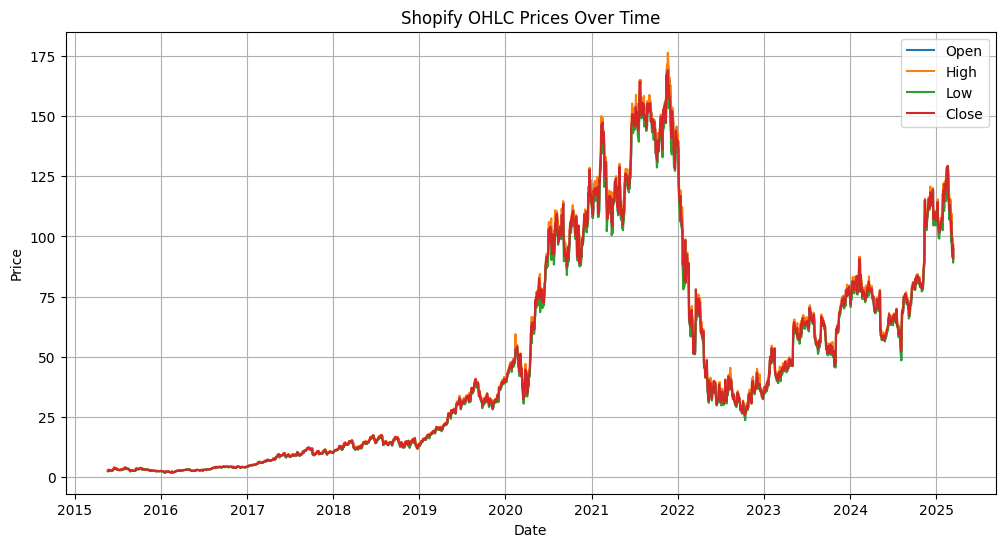

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['open'], label='Open')
plt.plot(df['date'], df['high'], label='High')
plt.plot(df['date'], df['low'], label='Low')
plt.plot(df['date'], df['close'], label='Close')
plt.title('Shopify OHLC Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

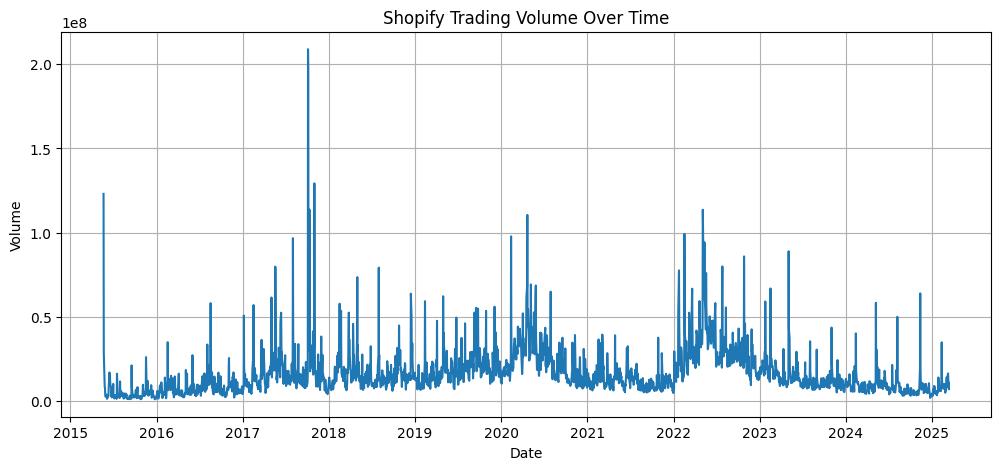

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['volume'])
plt.title('Shopify Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid()
plt.show()

In [26]:
df['Daily_Return'] = df['close'].pct_change() * 100
df.head()

,date,open,high,low,close,adj_close,volume,Daily_Return
0,2015-05-21 04:00:00+00:00,2.800,2.874,2.411,2.568,2.568,123039000,NaN
1,2015-05-22 04:00:00+00:00,2.607,3.110,2.600,2.831,2.831,28412000,10.241433
2,2015-05-26 04:00:00+00:00,2.980,3.034,2.908,2.965,2.965,8202000,4.733303
3,2015-05-27 04:00:00+00:00,3.067,3.081,2.700,2.750,2.750,7976000,-7.251262
4,2015-05-28 04:00:00+00:00,2.755,2.774,2.648,2.745,2.745,4000000,-0.181822


In [28]:
df['MA_20'] = df['close'].rolling(window=20).mean()

In [30]:
df['MA_50'] = df['close'].rolling(window=50).mean()

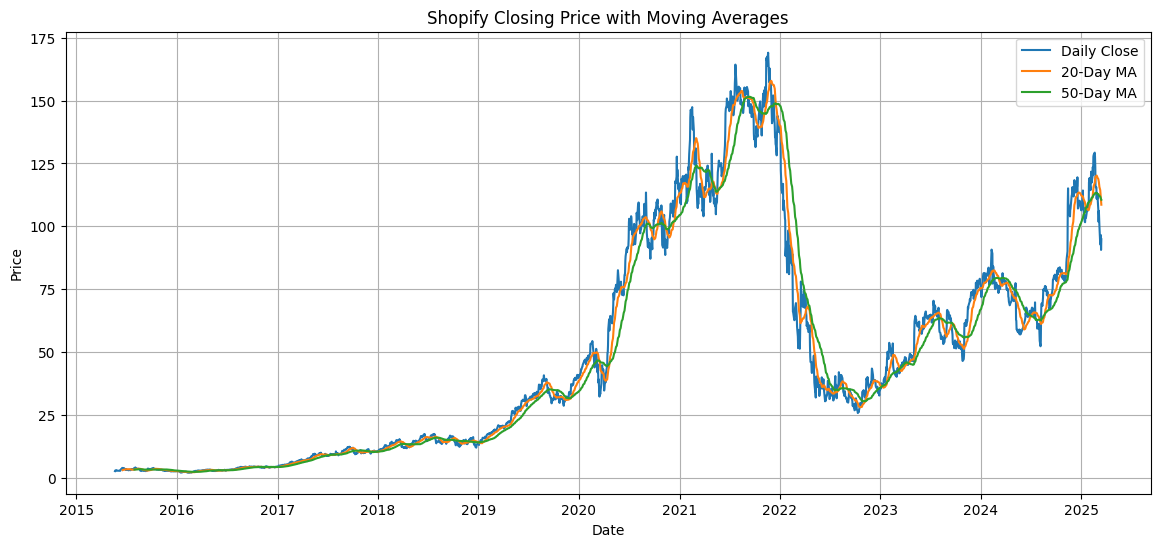

In [33]:
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['close'], label='Daily Close')
plt.plot(df['date'], df['MA_20'], label='20-Day MA')
plt.plot(df['date'], df['MA_50'], label='50-Day MA')
plt.title('Shopify Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

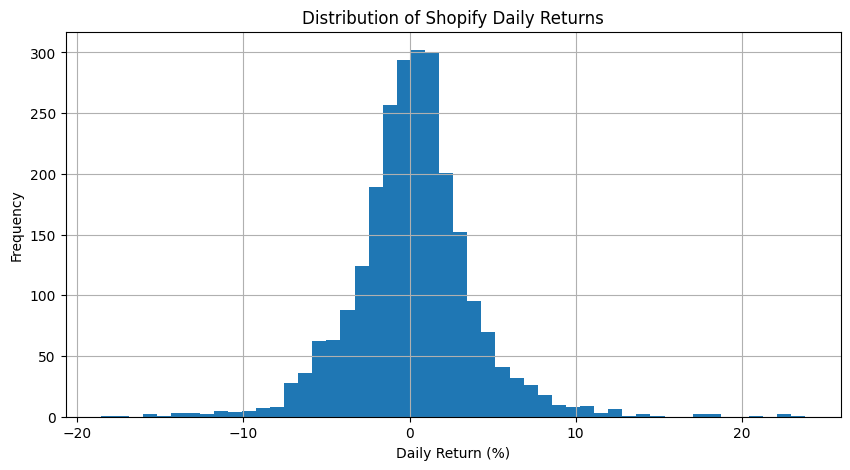

In [34]:
plt.figure(figsize=(10, 5))
plt.hist(
    df['Daily_Return'].dropna(),
    bins=50
)
plt.title('Distribution of Shopify Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid()
plt.show()

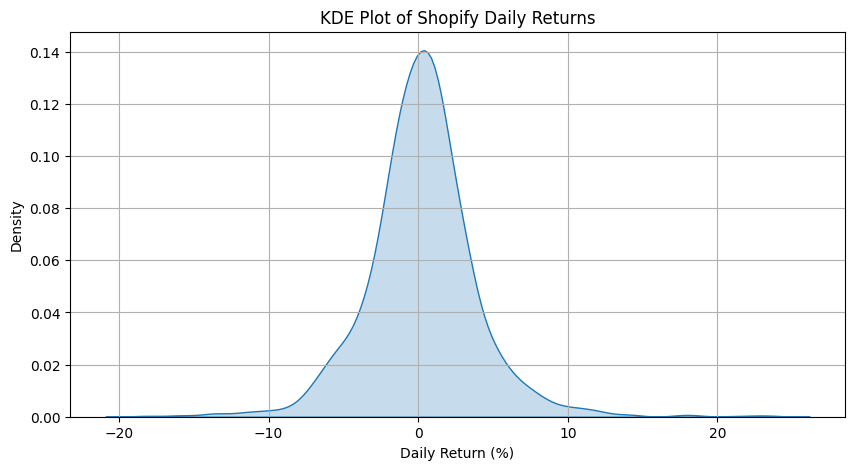

In [35]:
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.kdeplot(
    df['Daily_Return'].dropna(),
    fill=True
)
plt.title('KDE Plot of Shopify Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Density')
plt.grid()
plt.show()

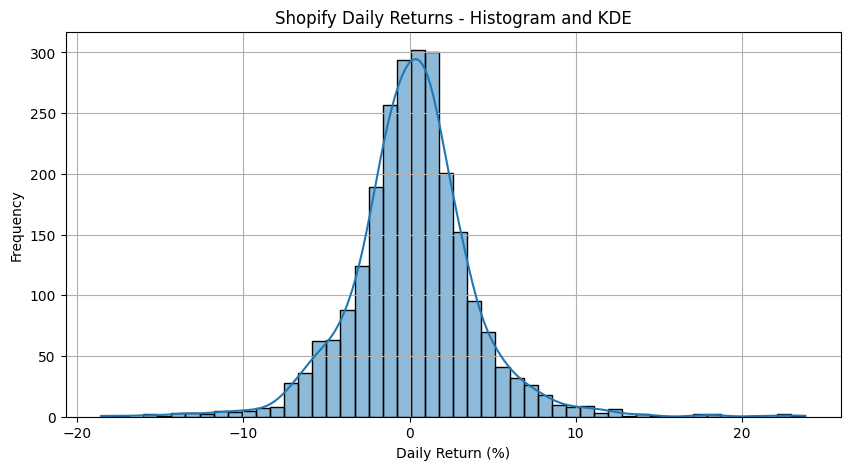

In [36]:
plt.figure(figsize=(10, 5))
sns.histplot(
    df['Daily_Return'].dropna(),
    bins=50,
    kde=True
)
plt.title('Shopify Daily Returns - Histogram and KDE')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid()
plt.show()

In [37]:
volatility = df['Daily_Return'].std()
print("Daily Volatility:", volatility, "%")

Daily Volatility: 3.712243534903458 %


In [39]:
mean_return = df['Daily_Return'].mean()
std_return = df['Daily_Return'].std()
high_volatility = df[
    abs(df['Daily_Return'] - mean_return) > 2 * std_return
]
print(high_volatility[
    ['date', 'close', 'Daily_Return']
])

                          date       close  Daily_Return
1    2015-05-22 04:00:00+00:00    2.831000     10.241433
3    2015-05-27 04:00:00+00:00    2.750000     -7.251262
14   2015-06-11 04:00:00+00:00    3.073000      9.359431
15   2015-06-12 04:00:00+00:00    3.363000      9.437031
19   2015-06-18 04:00:00+00:00    3.555000     -7.973074
...                        ...         ...           ...
2318 2024-08-07 04:00:00+00:00   63.889999     17.834744
2386 2024-11-12 05:00:00+00:00  108.919998     21.035671
2411 2024-12-18 05:00:00+00:00  109.699997     -8.193155
2436 2025-01-28 05:00:00+00:00  117.449997      9.377910
2464 2025-03-10 04:00:00+00:00   92.750000     -7.370416

[124 rows x 3 columns]


In [42]:
highest_gain = df.loc[
    df['Daily_Return'].idxmax()
]
highest_loss = df.loc[
    df['Daily_Return'].idxmin()
]
print("Highest Gain:")
print(highest_gain[['date', 'Daily_Return']])
print("\nHighest Loss:")
print(highest_loss[['date', 'Daily_Return']])

Highest Gain:
date            2023-05-04 04:00:00+00:00
Daily_Return                    23.838337
Name: 2002, dtype: object

Highest Loss:
date            2024-05-08 04:00:00+00:00
Daily_Return                   -18.585338
Name: 2256, dtype: object


In [44]:
print("===== SHOPIFY STOCK FINANCIAL SUMMARY ====")
print("Start Date:", df['date'].min())
print("End Date:", df['date'].max())
print("Starting Price:", df['close'].iloc[0])
print("Ending Price:", df['close'].iloc[-1])
print("Highest Price:", df['high'].max())
print("Lowest Price:", df['low'].min())
print("Average Closing Price:", df['close'].mean())
print("Average Daily Return:", df['Daily_Return'].mean(), "%")
print("Daily Volatility:", df['Daily_Return'].std(), "%")
print("Number of High-Volatility Days:", len(high_volatility))

===== SHOPIFY STOCK FINANCIAL SUMMARY ====
Start Date: 2015-05-21 04:00:00+00:00
End Date: 2025-03-14 04:00:00+00:00
Starting Price: 2.568000078201294
Ending Price: 94.8499984741211
Highest Price: 176.2917938232422
Lowest Price: 1.8480000495910645
Average Closing Price: 48.456613186980704
Average Daily Return: 0.21480626556944574 %
Daily Volatility: 3.712243534903458 %
Number of High-Volatility Days: 124
